In [1]:

import os
import sys
import argparse
import datetime
import numpy as np
import time
import torch
import torch.backends.cudnn as cudnn
import json
from pathlib import Path
from collections import OrderedDict
from functools import partial

# Add project root to path
# sys.path.insert(0, str(Path(__file__).parent))

from timm.models import create_model
from timm.loss import LabelSmoothingCrossEntropy, SoftTargetCrossEntropy
from timm.scheduler import create_scheduler
from src.optim.optim_factory import create_optimizer, get_parameter_groups, LayerDecayValueAssigner

from timm.utils import ModelEma

from src.utils.config import get_cfg, merge_config_file, freeze_cfg, load_and_freeze_config
from src.engine.train_engine import TrainingEngine
from src.engine.val_engine import ValidationEngine
from src.utils.evaluation import merge_distributed_results
from src.optim.mixup import Mixup
# from src.optim.optim_factory import LayerDecayValueAssigner
from src.dataset.datasets import build_dataset
from src.utils.utils import NativeScalerWithGradNormCount as NativeScaler
from src.utils.utils import multiple_samples_collate
from src.utils.logger import TensorboardLogger
from src.utils import utils

from src.models import ViT, ViT_pretrain, layers

from run_finetuning_with_yacs import create_data_loaders, create_model_from_config
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
config_path = '/root/lfz/Facial-Foundation-Model/output/adapter/dfew_128/config.yaml'
cfg = get_cfg()
merge_config_file(cfg, config_path)
cfg.SYSTEM.DISTRIBUTED = False  # Disable distributed training
# cfg.batch_size = 2  # Set batch size to 2
data_loader_train, data_loader_val = create_data_loaders()
model = create_model_from_config()

model_path = "/root/lfz/Facial-Foundation-Model/output/adapter/dfew_128/checkpoint-best.pth"
state_dict = torch.load(model_path, map_location='cpu', weights_only=False)
state_dict = state_dict["model"]
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

Number of the class = 7
Number of the class = 7
==> Note: use custom model depth=16!


==> Note: Use 'local_global' for compute reduction (lg_region_size=[2, 2, 10],lg_first_attn_type=self, lg_third_attn_type=cross,lg_attn_param_sharing_first_third=False,lg_attn_param_sharing_all=False,lg_classify_token_type=region,lg_no_second=False, lg_no_third=False)
==> Number of local regions: 20 (size=[4, 5, 1])
model after create_model = VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv3d(3, 512, kernel_size=(2, 16, 16), stride=(2, 16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0): LGBlock(
      (first_attn_norm0): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
      (first_attn): GeneralAttention(
        (q): Linear(in_features=512, out_features=512, bias=False)
        (kv): Linear(in_features=512, out_features=1024, bias=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=512, out_features=512, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (adapt

<All keys matched successfully>

In [3]:
samples, targets, _, _ = next(iter(data_loader_train))
target_reg = targets[...,1:]

In [4]:
def create_criterion_from_config():
    """Create loss criterion from global configuration."""
    cfg = get_cfg()
    
    if cfg.DATA.TASK == 'regression':
        if cfg.GAZE.USE_L2CS:
            from src.utils.gaze import l2cs_criterion
            criterion = l2cs_criterion
        else:
            criterion = torch.nn.MSELoss()
    elif cfg.DATA.TASK == "combine":
        criterion = {
            "cls_criterion": torch.nn.CrossEntropyLoss(),
            "reg_criterion": torch.nn.MSELoss()
        }

    else:
        # Classification task
        mixup_active = cfg.AUGMENTATION.MIXUP > 0 or cfg.AUGMENTATION.CUTMIX > 0
        if mixup_active:
            # Mixup mode
            criterion = SoftTargetCrossEntropy()
        elif cfg.AUGMENTATION.LABEL_SMOOTHING > 0:
            # Label smoothing
            criterion = LabelSmoothingCrossEntropy(smoothing=cfg.AUGMENTATION.LABEL_SMOOTHING)
        else:
            # Standard cross entropy
            criterion = torch.nn.CrossEntropyLoss()
    
    return criterion

In [ ]:
# Gradient-based Saliency Visualization
import torch.nn.functional as F

def compute_gradient_saliency(model, input_tensor, target_value, output_type='gaze', use_guided_backprop=True):
    """
    Compute gradient of output w.r.t. input with improved visualization
    Args:
        model: the model
        input_tensor: input tensor (requires_grad=True)
        target_value: target value for computing gradient
        output_type: 'gaze' or 'emo'
        use_guided_backprop: whether to use guided backpropagation
    Returns:
        saliency map
    """
    target = torch.zeros(1, 7)
    target[0, target_value] = 1
    print(target)
    model.eval()
    input_tensor.requires_grad_(True)
    
    # Clear any existing gradients
    if input_tensor.grad is not None:
        input_tensor.grad.zero_()
    
    # Forward pass
    output,_ = model(input_tensor)
    print(output)
    print(output.shape)
    
    if output_type == 'gaze':
        # For gaze regression, use output magnitude instead of loss
        # This gives stronger gradients for visualization
        output_gaze = output["reg"]
        output_gaze = output_gaze.reshape(-1, cfg.DATA.NUM_FRAMES, 2)
        # Use L2 norm of prediction as the target to maximize
        target_magnitude = torch.norm(output_gaze, dim=-1).mean()
        loss = target_magnitude
    elif output_type == 'emo':
        criterion = create_criterion_from_config()
        loss = criterion(output, target)
        # For emotion classification, use max logit
        # print(output)
        # output_emo = output["cls"]
        # output_emo = output_emo.reshape(-1, cfg.DATA.NUM_FRAMES, cfg.DATA.NUM_CLASSES)
        # bsz = input_tensor.shape[0]
        # cls_pred = output_emo.reshape(bsz, -1, cfg.DATA.NUM_CLASSES).mean(1)
        # # Use the maximum predicted class score
        # max_score = torch.max(cls_pred, dim=-1)[0].mean()
        # loss = max_score
        
    
    # Backward pass to compute gradients
    loss.backward()
    
    print(f"[DEBUG] grad of input_tensor {input_tensor.grad.shape}, range: [{input_tensor.grad.min():.6f}, {input_tensor.grad.max():.6f}]")
    
    # Get gradients w.r.t. input and enhance them
    saliency = input_tensor.grad.data.abs()  # Take absolute value
    
    # Enhance gradient visualization by normalizing per sample
    for i in range(saliency.shape[0]):
        sample_grad = saliency[i]
        # Normalize to [0, 1] range for better visualization
        sample_min = sample_grad.min()
        sample_max = sample_grad.max()
        if sample_max > sample_min:
            saliency[i] = (sample_grad - sample_min) / (sample_max - sample_min)
    
    return saliency, loss.item()

print("Gradient saliency computation function defined")

Gradient saliency computation function defined


In [6]:
def create_saliency_overlay(original_frames, saliency_map, alpha=0.6):
    """
    Create overlay of saliency map on original frames with improved visualization
    Args:
        original_frames: numpy array of shape (T, H, W, 3)
        saliency_map: numpy array of shape (T, H, W) 
        alpha: transparency of overlay
    Returns:
        overlayed frames
    """
    import matplotlib.cm as cm
    import scipy.ndimage as ndimage
    
    # Apply Gaussian smoothing to reduce patch artifacts
    smoothed_saliency = np.zeros_like(saliency_map)
    for t in range(saliency_map.shape[0]):
        # Smooth each frame to reduce grid patterns
        smoothed_saliency[t] = ndimage.gaussian_filter(saliency_map[t], sigma=2.0)
    
    # Enhance contrast using gamma correction
    gamma = 0.5  # Makes bright areas brighter
    saliency_enhanced = np.power(smoothed_saliency, gamma)
    
    # Normalize saliency map to [0, 1] with better dynamic range
    saliency_norm = np.zeros_like(saliency_enhanced)
    for t in range(saliency_enhanced.shape[0]):
        frame_sal = saliency_enhanced[t]
        # Use percentile normalization for better contrast
        p5, p95 = np.percentile(frame_sal, [5, 95])
        if p95 > p5:
            frame_sal_norm = np.clip((frame_sal - p5) / (p95 - p5), 0, 1)
        else:
            frame_sal_norm = frame_sal
        saliency_norm[t] = frame_sal_norm
    
    # Apply colormap (hot colormap for saliency)
    colormap = cm.get_cmap('hot') if hasattr(cm, 'get_cmap') else plt.cm.hot
    saliency_colored = colormap(saliency_norm)[:, :, :, :3]  # Remove alpha channel
    saliency_colored = (saliency_colored * 255).astype(np.uint8)
    
    # Create overlay with better blending
    overlayed = []
    for t in range(original_frames.shape[0]):
        # Use higher alpha for more visible saliency
        overlay = cv2.addWeighted(original_frames[t], 1-alpha, saliency_colored[t], alpha, 0)
        overlayed.append(overlay)
    
    return np.array(overlayed)

def save_saliency_video(original_frames, saliency_map, save_path, fps=5):
    """
    Save saliency visualization as video
    """
    overlayed_frames = create_saliency_overlay(original_frames, saliency_map)
    
    # Save video
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    height, width, _ = overlayed_frames[0].shape
    out = cv2.VideoWriter(save_path, fourcc, fps, (width, height))
    
    for frame in overlayed_frames:
        out.write(frame)
    out.release()
    
    return overlayed_frames

print("Saliency visualization functions defined")

Saliency visualization functions defined


tensor([[0., 0., 1., 0., 0., 0., 0.]])
tensor([[ 0.8296,  0.3140,  0.7256,  0.0505,  0.4756, -1.2634, -0.4979]],
       grad_fn=<AddmmBackward0>)
torch.Size([1, 7])


[DEBUG] grad of input_tensor torch.Size([1, 3, 16, 160, 160]), range: [-0.012889, 0.012786]


/tmp/ipykernel_2101/2668829527.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('hot') if hasattr(cm, 'get_cmap') else plt.cm.hot


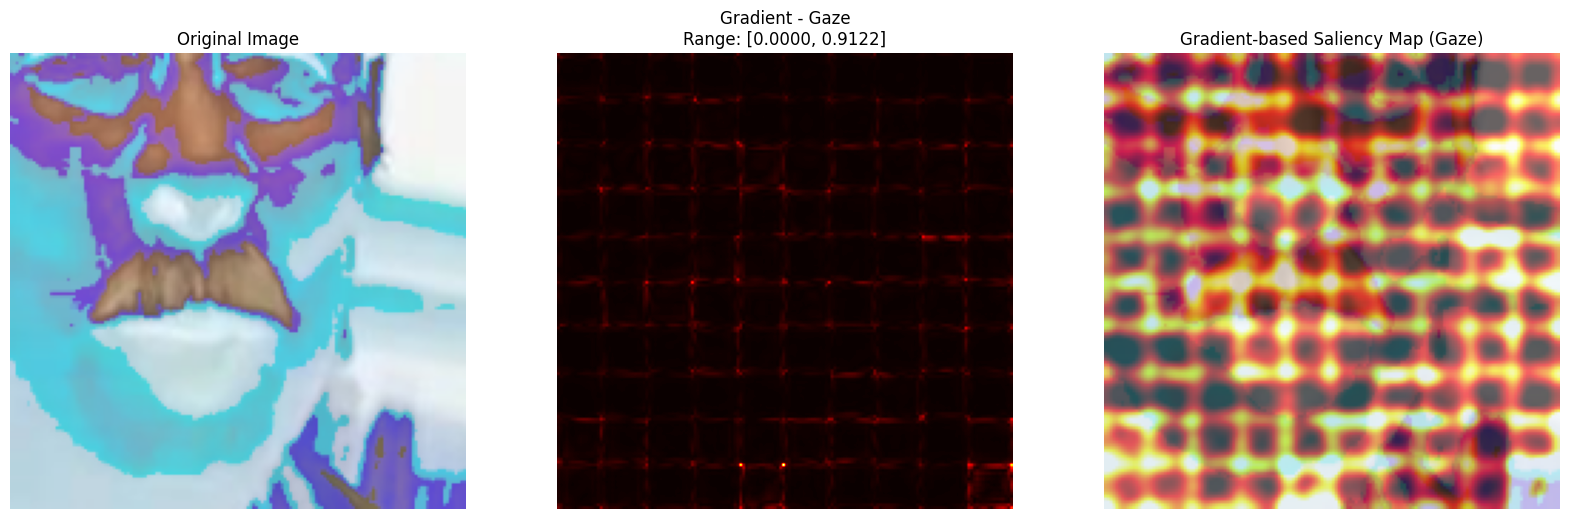

In [9]:
sample_input = samples[0:1].clone()
sample_target_reg = target_reg[0:1]
grad_sal_gaze, grad_loss_gaze = compute_gradient_saliency(
    model, sample_input.clone(), sample_target_reg, output_type='emo'
)

sample_vis = sample_input[0].permute(1, 2, 3, 0).detach().cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
sample_vis = (sample_vis * std + mean)
sample_vis = np.clip(sample_vis, 0, 1)
sample_vis = (sample_vis * 255).astype(np.uint8)

grad_gaze_np = grad_sal_gaze[0].permute(1, 2, 3, 0).mean(dim=-1).cpu().numpy()


frame_idx = 0
fig, axes = plt.subplots(1, 3, figsize=(20, 15))
# Original
axes[0].imshow(sample_vis[frame_idx])
axes[0].set_title('Original Image')
axes[0].axis('off')

# Standard gradients
axes[1].imshow(grad_gaze_np[frame_idx], cmap='hot')
axes[1].set_title(f'Gradient - Gaze\nRange: [{grad_gaze_np.min():.4f}, {grad_gaze_np.max():.4f}]')
axes[1].axis('off')

grad_gaze_overlay = create_saliency_overlay(sample_vis, grad_gaze_np)
axes[2].imshow(grad_gaze_overlay[frame_idx])
axes[2].set_title('Gradient Overlay')
axes[2].axis('off')

# plt.colorbar()
plt.title("Gradient-based Saliency Map (Gaze)")
plt.show()
